In [26]:
import mtest
import tfel.math
import tfel.tests
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import math
from ogs6py import ogs
import vtuIO
from ogs6py import ogs
import itertools
import pyvista as pv

# Some plot settings
#plt.style.use("seaborn-deep")
plt.rcParams["lines.linewidth"] = 2.0
plt.rcParams["lines.color"] = "black"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["legend.frameon"] = True
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.family"] = "serif"
plt.rcParams["legend.fontsize"] = 12
plt.rcParams['legend.framealpha'] = 0.4
plt.rcParams["font.size"] = 18
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.left"] = True
plt.rcParams["axes.spines.bottom"] = True
plt.rcParams["axes.axisbelow"] = True

In [2]:
def compute_chi(S_L, bishop_type, bishop_value):
    S_L = np.asarray(S_L)
    if bishop_type == 0:
        chi = S_L**bishop_value
    elif bishop_type == 1:
        S_cut = bishop_value
        chi = np.zeros_like(S_L, dtype=float)
        chi = np.where(S_L < S_cut, 0.0, chi)
        chi = np.where(S_L > 1.0, 1.0, chi)
        mask = (S_L >= S_cut) & (S_L <= 1.0)
        chi = np.where(mask, (S_L - S_cut) / max(1e-12, 1.0 - S_cut), chi)
    else:
        raise ValueError("bishop_type must be 0 (power-law) or 1 (cutoff)")
    return chi


def compute_initial_values(sigma_pre, bishop_type, bishop_value, alpha_B, p_b, m_S, S_L_res, S_G_res,
    S_L: float = None,
    p0: float = None):
    if (S_L is None) == (p0 is None):
        raise ValueError("Must provide exactly one of 'S_L' or 'p0', not both or neither.")

    if S_L is not None:
        S_e = (S_L - S_L_res) / (1 - S_L_res - S_G_res)
        p_cap = p_b * ((S_e)**(-1/m_S) - 1)**(1-m_S)
        p0 = -p_cap

    else:
        p_cap = -p0
        f = (p_cap / p_b)**(1/(1-m_S))
        S_e = (1 + f)**(-m_S)
        S_L = S_e * (1 - S_L_res - S_G_res) + S_L_res

    chi = compute_chi(S_L, bishop_type, bishop_value)

    sigma_total = sigma_pre - alpha_B * chi * p0

    print(f"initial stress (total): {np.round(sigma_total,8)}")
    print(f"initial fluid pressure: {np.round(p0,2)}")
    print(f"initial liquid saturation: {np.round(S_L,14)}")

    return sigma_total, p0, S_L


In [37]:
# only strain driven for the time being
# Caution: uniaxial : works for both Bishops Power law and cutoff
#          triaxial : works with Cutoff only for the time being
test_type = "triaxial"

# Bishops model settings:
bishops_model_type  = 1 # only 0: power law model or 1: cutoff model are allowed
bishops_model_value = 1

assert test_type in ("uniaxial", "triaxial"), f"Invalid test_type: {test_type}"
assert (test_type != "triaxial") or (bishops_model_type != 0), "Triaxial test is not set up to work with Bishop's Power Law yet."

temperature_ic = 293
temperature_bc = 100 + temperature_ic
# swelling stress settings:
pmax   = 4e6
exp_p  = 1
Smin_p = 0
Smax_p = 1

alpha = 1e-5
intrinsic_permeability = 1e-21

# Biot-willis coefficient
alpha_B = 1

# van-Genuchten saturation settings (relative_permeability settings need to be changed in the project file directly)
p_l = -40e6*1 ; p_b = 16e6; m_S = 0.4014347581153

S_L_res = 0.0
S_G_res = 0.0

nu = 0.3  # Poisson ratio
la = 7.7e-2  # Slope of the virgin consolidation line
ka = 6.6e-3  # Slope of the swelling line
M = 1.2  # Slope of the critical state line (CSL)
phi = 0.4
v0 = 1/(1-phi)  # Initial volume ratio

pc0 = 5e6 #Initial pre-consolidation pressure in Pa

sig_pre_eff = -5e6


initial_stress, pressure_ic, S_L = compute_initial_values(sig_pre_eff, bishops_model_type, bishops_model_value, alpha_B, p_b, m_S, S_L_res, S_G_res, 
                                    p0 = p_l)
pressure_final = 0

days = 100
interval = 2
t_list =[86400.0*t for t in np.arange(0, days + 1, interval)]
t_end  = t_list[-1]
init_dt = 1#*86400

E = 3 * (1 - 2 * nu) / (1 - phi) * pc0 / ka

e_axi = 0.02
print(E)
  

initial stress (total): -5000000.0
initial fluid pressure: -40000000.0
initial liquid saturation: 0.5000000000002
1515151515.1515155


In [38]:
f_mfront = "saturation.prj"
f_mfront_coupled = "saturation_coupled.prj"
def modify_prj():
    model = ogs.OGS(INPUT_FILE=f_mfront, PROJECT_FILE=f_mfront)
    model.remove_element("./media/medium/properties/property[name='saturation']")
    model.add_block("property", parent_xpath="./media/medium/properties", 
                   taglist=["name","type","p_b","exponent","residual_liquid_saturation","residual_gas_saturation"], 
                    textlist=["saturation", "SaturationVanGenuchten", p_b, m_S, S_L_res, S_G_res])

    model.remove_element("./media/medium/properties/property[name='bishops_effective_stress']")
    if bishops_model_type == 0:
        model.add_block("property", parent_xpath="./media/medium/properties", 
                   taglist=["name","type","exponent"], textlist=["bishops_effective_stress", "BishopsPowerLaw", bishops_model_value])

    elif bishops_model_type == 1:
        model.add_block("property", parent_xpath="./media/medium/properties", 
                   taglist=["name","type","cutoff_value"], textlist=["bishops_effective_stress", "BishopsSaturationCutoff", bishops_model_value])
    else:
        raise ValueError("bishop_type must be 0 (power-law) or 1 (cutoff)")

    model.remove_element("./media/medium/phases/phase[type='Solid']/properties/property[name='swelling_stress_rate']")
    model.add_block("property", parent_xpath="./media/medium/phases/phase[type='Solid']/properties", 
               taglist=["name","type","swelling_pressures","exponents","lower_saturation_limit","upper_saturation_limit"],
               textlist=["swelling_stress_rate", "SaturationDependentSwelling",f"{pmax} {pmax} {pmax}",f"{exp_p} {exp_p} {exp_p}", f"{Smin_p}",f"{Smax_p}"])
    
    model.replace_parameter("temperature_ic", "Constant", ["value"], [temperature_ic])
    model.replace_parameter("alpha", "Constant", ["value"], [alpha])
    model.replace_parameter("alpha_B", "Constant", ["value"], [alpha_B])
    model.replace_parameter("bishops_model_type", "Constant", ["value"], [bishops_model_type])
    model.replace_parameter("bishops_model_value", "Constant", ["value"], [bishops_model_value])

    model.replace_parameter("E", "Constant", ["value"], [E])
    model.replace_parameter("nu", "Constant", ["value"], [nu])
    model.replace_parameter("M", "Constant", ["value"], [M])
    model.replace_parameter("ka", "Constant", ["value"], [ka])
    model.replace_parameter("la", "Constant", ["value"], [la])
    model.replace_parameter("pc0", "Constant", ["value"], [pc0])
    model.replace_parameter("v0", "Constant", ["value"], [v0])
    model.replace_parameter("phi", "Constant", ["value"], [phi])

    model.replace_parameter("intrinsic_permeability", "Constant", ["value"], [intrinsic_permeability])
    model.replace_parameter("p_b", "Constant", ["value"], [p_b])
    model.replace_parameter("m_S", "Constant", ["value"], [m_S])
    model.replace_parameter("S_L_res", "Constant", ["value"], [S_L_res])
    model.replace_parameter("S_G_res", "Constant", ["value"], [S_G_res])

    model.replace_parameter("initial_stress", "Constant", ["values"], [f"{initial_stress} {initial_stress} {initial_stress} 0.0"])
    model.replace_parameter("pressure_ic", "Constant", ["value"], [pressure_ic])
    model.replace_parameter("disp_value", "Constant", ["value"], [-e_axi])
    
    model.remove_element("./curves/curve[name='pressure_ramp_curve']")
    model.add_block("curve", parent_xpath="./curves", 
                   taglist=["name","coords","values"], 
                    textlist=["pressure_ramp_curve", f"0.0 {t_end}", f"1.0 {pressure_final/pressure_ic if pressure_ic!=0 else 0}"])
    model.remove_element("./curves/curve[name='temperature_curve']")
    model.add_block("curve", parent_xpath="./curves", 
                   taglist=["name","coords","values"], 
                    textlist=["temperature_curve", f"0.0 {t_end}", f"{temperature_ic} {temperature_bc}"])
    
    model.remove_element("./curves/curve[name='ax_disp_curve']")
    model.add_block("curve", parent_xpath="./curves", 
                   taglist=["name","coords","values"], 
                    textlist=["ax_disp_curve", f"0.0 {t_end}", "0 1"])
    
    
    model.remove_element("./curves/curve[name='pre_loading_curve']")
    model.add_block("curve", parent_xpath="./curves", 
                   taglist=["name","coords","values"], 
                    textlist=["pre_loading_curve", f"0.0 {t_end}", f"{initial_stress} {initial_stress}"])
    
    
    model.remove_element("./process_variables/process_variable[name='displacement']/boundary_conditions/boundary_condition[geometry='right']")
    bc_type = "Dirichlet"; bc_parameter = "dirichlet0"
    if test_type == "triaxial":
        bc_type = "Neumann"; bc_parameter = "confining_pressure"
    model.add_block("boundary_condition", parent_xpath="./process_variables/process_variable[name='displacement']/boundary_conditions",
                   taglist=["geometrical_set","geometry", "component","type","parameter"],
                   textlist=["square_1x1_geometry","right","0", bc_type, bc_parameter])
    
    
    model.replace_text(f_mfront[:-4], xpath="./time_loop/output/prefix")
    model.replace_text(t_end, xpath="./time_loop/processes/process/time_stepping/t_end")
    model.replace_text(init_dt, xpath="./time_loop/processes/process/time_stepping/initial_dt")
    model.replace_text(t_end*interval/days, xpath="./time_loop/processes/process/time_stepping/maximum_dt")
    model.replace_text(" ".join(str(t) for t in t_list), xpath="./time_loop/output/fixed_output_times")
    
    model.write_input()
    
    # second .prj
    model = ogs.OGS(INPUT_FILE=f_mfront, PROJECT_FILE=f_mfront_coupled)

    m_path = "./processes/process/constitutive_relation/material_properties"
    props = ["InitialVolumeRatio", "ThermalExpansion", "BiotCoefficient", "BishopsModelType", "BishopsModelValue", 
            "ResidualLiquidSaturation", "ResidualGasSaturation", "BubblePressure", "VanGenuchtenExponent_m",
            "SwellingPressures", "Exponents", "LowerSaturationLimit", "UpperSaturationLimit"]
    params = ["v0", "alpha", "alpha_B", "bishops_model_type", "bishops_model_value", "S_L_res", "S_G_res", "p_b", "m_S", "pmax", "exp_p", "Smin_p", "Smax_p"]
    
    model.remove_element(m_path+"/material_property[@name='YoungModulus']")
    model.remove_element(m_path+"/material_property[@name='InitialVolumeRatio']")
    for i in range(len(props)):
        model.add_block(blocktag="material_property", block_attrib={"name": props[i], "parameter": params[i]}, parent_xpath=m_path)
    
    model.processes.add_secondary_variable(internal_name="sigma_total", output_name="sigma_total")
    model.remove_element("./processes/process/secondary_variables/secondary_variable[@internal_name='sigma']")
    model.replace_text("StressSaturation_StrainPressureTemperature", xpath="./processes/process/subtype")
    model.replace_text("ModCamClay_semiExpl_coupled", xpath="./processes/process/constitutive_relation/behaviour")
    model.replace_text(f_mfront_coupled[:-4], xpath="./time_loop/output/prefix")
    model.deactivate_property(name="swelling_stress_rate", mediumid=0, phase="Solid")
    model.parameters.add_parameter(name="pmax", type="Constant", value=pmax)
    model.parameters.add_parameter(name="exp_p", type="Constant", value=exp_p)
    model.parameters.add_parameter(name="Smin_p", type="Constant", value=Smin_p)
    model.parameters.add_parameter(name="Smax_p", type="Constant", value=Smax_p)
    model.write_input()
modify_prj()

#!diff saturation.prj saturation_coupled.prj

## Run OGS simulations

In [39]:
run_ogs = True
ogs_source_dir = os.getcwd()[
    : -len("/Tests/Data/ThermoRichardsMechanics/MFront/TRM_MCC_coupled")
]
assert os.path.exists(ogs_source_dir)
ogs_build_dir = os.path.join(ogs_source_dir, "build")
assert os.path.exists(ogs_build_dir)
ogs_path = os.path.realpath(os.path.join(ogs_build_dir, "bin/ogs"))
assert os.path.exists(ogs_path)

if run_ogs:
    !rm out/*
    #"""
    start = time.time()
    assert (
        os.system(
            f"{ogs_path} -o out {f_mfront} > ogs.log 2>&1"
        )
        == 0
    )
    e = int(time.time() - start)
    print('MFront run time = {:02d}:{:02d}:{:02d}(h:m:s)'.format(e // 3600, (e % 3600 // 60), e % 60))
    #"""
    
    start = time.time()
    assert (
        os.system(
            f"{ogs_path} -o out {f_mfront_coupled} > ogs.log 2>&1"
        )
        == 0
    )
    e = int(time.time() - start)
    print('MFront run time = {:02d}:{:02d}:{:02d}(h:m:s)'.format(e // 3600, (e % 3600 // 60), e % 60))

MFront run time = 00:00:00(h:m:s)
MFront run time = 00:00:20(h:m:s)


In [40]:
behaviors_dir = "/MaterialLib/SolidModels/MFront/ModCamClay_semiExpl_coupled.mfront"
MCC_coupled_path = ogs_source_dir + behaviors_dir
# Uncomment below line once and if there is a change in mfront model (which may require restart of the notebook)
#!rm -rf include src && mfront --obuild --interface=generic $MCC_coupled_path

## MTest

In [42]:
def saturation_mtest():  
    #test.setVerboseMode(mtest.VerboseLevel.VERBOSE_LEVEL3)
    mtest.setVerboseMode(mtest.VerboseLevel.VERBOSE_QUIET)
    m = mtest.MTest()
    m.setMaximumNumberOfSubSteps(1)
    m.setModellingHypothesis("Axisymmetrical")
    m.setBehaviour("generic", "./src/libBehaviour.so","ModCamClay_semiExpl_coupled")
    m.setGradientsInitialValues([0,0,0,0, pressure_ic])
    m.setThermodynamicForcesInitialValues([initial_stress, initial_stress, initial_stress, 0.0, S_L]) #check

    m.setImposedGradient("StrainRZ", 0.0)

    m.setImposedGradient("StrainZZ", {0: 0, t_end: -e_axi})
        
    if test_type == "triaxial":  
        m.setImposedThermodynamicForce("StressRR", initial_stress)
        m.setImposedThermodynamicForce("StressTT", initial_stress)
    else:
        m.setImposedGradient("StrainRR", 0)
        m.setImposedGradient("StrainTT", 0)
        
        
    m.setImposedGradient("LiquidPressure", {0: pressure_ic, t_end: pressure_final})

    m.setExternalStateVariable("Temperature", {0: temperature_ic, t_end: temperature_bc})
    m.setMaterialProperty("PoissonRatio", nu)
    m.setMaterialProperty("CriticalStateLineSlope", M)
    m.setMaterialProperty("SwellingLineSlope", ka)
    m.setMaterialProperty("VirginConsolidationLineSlope", la)
    m.setMaterialProperty("CharacteristicPreConsolidationPressure", pc0)
    m.setMaterialProperty("InitialVolumeRatio", v0)

    m.setInternalStateVariableInitialValue("PreConsolidationPressure", pc0)
    m.setInternalStateVariableInitialValue("VolumeRatio", v0)
        
    m.setMaterialProperty("ThermalExpansion", alpha)
    m.setMaterialProperty("BiotCoefficient", alpha_B)
    m.setMaterialProperty("BishopsModelType", bishops_model_type)
    m.setMaterialProperty("BishopsModelValue", bishops_model_value)
    m.setMaterialProperty("ResidualLiquidSaturation", S_L_res)
    m.setMaterialProperty("ResidualGasSaturation", S_G_res)
    m.setMaterialProperty("BubblePressure", p_b)
    m.setMaterialProperty("VanGenuchtenExponent_m", m_S)
    
    m.setMaterialProperty("SwellingPressures", pmax)
    m.setMaterialProperty("Exponents", exp_p)
    m.setMaterialProperty("LowerSaturationLimit", Smin_p)
    m.setMaterialProperty("UpperSaturationLimit", Smax_p)
    m.setTimes(t_list)
    out = f"saturation_mtest.res"
    m.setOutputFileName(out)
    m.execute()
    print(f"MTest done!")

saturation_mtest()

MTest done!


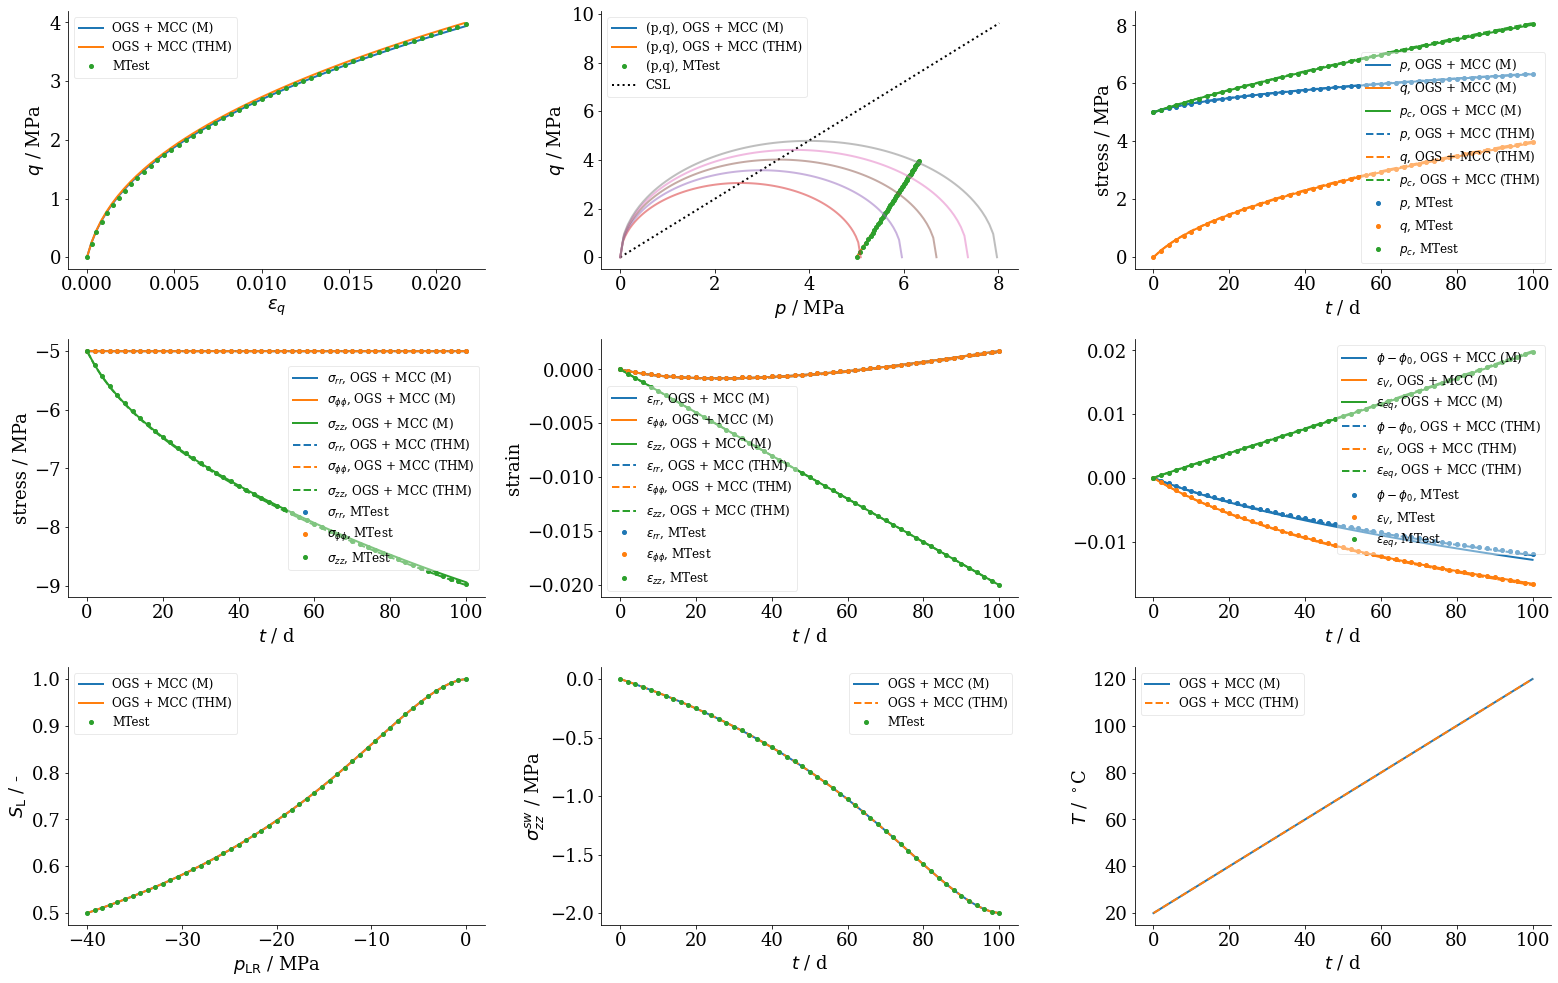

In [43]:
def read_ogs(pvd_file):
    reader = pv.get_reader(pvd_file)
    times, eps, sig, pc, eps_eq, vr, p_LR, S_L, sig_sw, T = [], [], [], [], [], [], [], [], [], []
    times = reader.time_values

    for ti, t in enumerate(times):
        reader.set_active_time_point(ti)
        mesh = reader.read()[0]
        #print(mesh.field_data.keys())
        eps.append(mesh.field_data["epsilon_ip"].mean(axis=0)[:3])
        if "sigma_total_ip" in mesh.field_data.keys():
            sig.append(mesh.field_data["sigma_total_ip"].mean(axis=0)[:3])
        else:
            sig.append(mesh.field_data["sigma_ip"].mean(axis=0)[:3])
        
        pc.append(mesh.point_data["PreConsolidationPressure"][0])
        eps_eq.append(mesh.point_data["EquivalentPlasticStrain"][0])
        vr.append(mesh.point_data["VolumeRatio"][0])     
        p_LR.append(mesh.point_data["pressure_interpolated"][0])
        S_L.append(mesh.field_data["saturation_ip"].mean(axis=0))
        sig_sw.append(mesh.point_data["swelling_stress"][0][:3])
        T.append(mesh.point_data["temperature_interpolated"][0]-273)
    times, eps, sig, pc, eps_eq, vr, p_LR, S_L, sig_sw  = np.array(times), np.array(eps), np.array(sig), np.array(pc), np.array(eps_eq), np.array(vr), np.array(p_LR), np.array(S_L), np.array(sig_sw)
    if "sigma_total_ip" in mesh.field_data.keys() and bishops_model_type == 0:
        chi = compute_chi(S_L, bishops_model_type, bishops_model_value)
        #print(chi)
        for comp in range(3):
            sig[:, comp] += alpha_B * chi * p_LR
        
    return (times, eps, sig, pc, eps_eq, vr, p_LR, S_L, sig_sw, T)
def plot_mtest_results_vtu(pvd_files, plt_mtest = False, n_ellipse=5, n_points=100):
    data = np.loadtxt("saturation_mtest.res")
    time = data[:,0]/86400
    m_eps  = data[:,1:4]
    m_p_LR = data[:,5]
    m_sig  = data[:,6:9]
    m_S_L  = data[:,10]
    m_sig_sw  = data[:,11:14]
    m_eps_eq = data[:,19]
    m_pc   = data[:,20]
    m_vr   = data[:,22]
   
    m_ls = 'None' # line style for mtest
    m_ms = 4 # marker size for mtest
    
    m_chi = compute_chi(m_S_L, bishops_model_type, bishops_model_value)
    for comp in range(3):
        m_sig[:, comp] += alpha_B * m_chi * m_p_LR
        
    m_eps_mean = np.mean(m_eps,axis=1)
    m_sig_mean = np.mean(m_sig,axis=1)
    m_dev_eps  = m_eps - m_eps_mean[:,None]
    m_dev_sig  = m_sig - m_sig_mean[:,None]
    m_eps_dev  = np.sqrt(1.5*np.sum(m_dev_eps**2,axis=1))
    m_q        = np.sqrt(1.5*np.sum(m_dev_sig**2,axis=1))
    m_p        = -m_sig_mean
    
    # Load reference dataset
    t_0, eps_0, sig_0, pc_0, eps_eq_0, vr_0, p_LR_0, S_L_0, sig_sw0, T0 = read_ogs(pvd_files[0])
    
    eps_mean_0 = np.mean(eps_0, axis=1)
    sig_mean_0 = np.mean(sig_0, axis=1)
    dev_eps_0  = eps_0 - eps_mean_0[:, None]
    dev_sig_0  = sig_0 - sig_mean_0[:, None]
    eps_dev_0  = np.sqrt(1.5 * np.sum(dev_eps_0**2, axis=1))
    q_0        = np.sqrt(1.5 * np.sum(dev_sig_0**2, axis=1))
    p_0        = -sig_mean_0
    
    #np.savetxt('MTest.txt', np.c_[time, m_S_L, m_p_LR, m_sig_sw[:, 1], m_sig, m_p, m_q, m_pc, m_eps_eq, m_vr], fmt='%12.8g', header='time S_L p_LR swellingZZ sigmaRR sigmaZZ sigmaTT p q pc eps_eq v_r', comments='')
    
    fig, ((ax0,ax1,ax2),(ax3,ax4,ax5),(ax6,ax7,ax8)) = plt.subplots(3,3,figsize=(22,14))
    
    for idx, pvd in enumerate(pvd_files):
        label   = "OGS + MCC (M)"
        if "coupled" in os.path.basename(pvd)[:-4]:
            label = "OGS + MCC (THM)"
        t, eps, sig, pc, eps_eq, vr, p_LR, S_L, sig_sw, T = read_ogs(pvd)
        t = t/86400
        eps_mean = np.mean(eps, axis=1)
        sig_mean = np.mean(sig, axis=1)
        dev_eps  = eps - eps_mean[:, None]
        dev_sig  = sig - sig_mean[:, None]
        eps_dev  = np.sqrt(1.5 * np.sum(dev_eps**2, axis=1))
        q        = np.sqrt(1.5 * np.sum(dev_sig**2, axis=1))
        p        = -sig_mean
        
        ################## plotting starts here
        # q vs epsilon_dev
        ax0.plot(eps_dev, q*1e-6, label=label)
        #ax0.set_prop_cycle(None)
        if plt_mtest == True and idx:
            ax0.plot(m_eps_dev, m_q*1e-6, marker='o', markersize= m_ms, linestyle=m_ls, label="MTest")

        # p-q locus + quiver
        ax1.plot(p*1e-6, q*1e-6, label=f"(p,q), {label}")
        #ax1.set_prop_cycle(None)
        if plt_mtest == True and idx:
            ax1.plot(m_p*1e-6, m_q*1e-6, marker='o', markersize= m_ms, linestyle=m_ls, label=f"(p,q), MTest")
        #ax1.quiver(p[:-1], q[:-1], np.diff(p), np.diff(q), angles='xy', scale_units='xy', scale=1, width=0.005)

        # Time-series: p, q, p_c
        ax2.plot(t, p*1e-6, linestyle='--' if idx else '-', label=f"$p$, {label}")
        ax2.plot(t, q*1e-6, linestyle='--' if idx else '-', label=f"$q$, {label}")
        ax2.plot(t, pc*1e-6, linestyle='--' if idx else '-', label=f"$p_c$, {label}")
        ax2.set_xlabel("$t$ / d")
        ax2.set_ylabel("stress / MPa")
        ax2.set_prop_cycle(None)
        if plt_mtest == True and idx:
            ax2.plot(time, m_p*1e-6, marker='o', markersize= m_ms, linestyle=m_ls, label=f"$p$, MTest")
            ax2.plot(time, m_q*1e-6, marker='o', markersize= m_ms, linestyle=m_ls, label=f"$q$, MTest")
            ax2.plot(time, m_pc*1e-6, marker='o', markersize= m_ms, linestyle=m_ls, label=f"$p_c$, MTest")
        ax2.legend()

        # Stress components
        ax3.plot(t, sig[:, 0]*1e-6, linestyle='--' if idx else '-', label=r"$\sigma_{rr}$, " + label)
        ax3.plot(t, sig[:, 2]*1e-6, linestyle='--' if idx else '-', label=r"$\sigma_{\phi\phi}$, " + label)
        ax3.plot(t, sig[:, 1]*1e-6, linestyle='--' if idx else '-', label=r"$\sigma_{zz}$, " + label)
        ax3.set_xlabel("$t$ / d")
        ax3.set_ylabel("stress / MPa")
        ax3.set_prop_cycle(None)
        if plt_mtest == True and idx:
            ax3.plot(time, m_sig[:, 0]*1e-6, marker='o', markersize= m_ms, linestyle=m_ls, label=r"$\sigma_{rr}$, MTest")
            ax3.plot(time, m_sig[:, 2]*1e-6, marker='o', markersize= m_ms, linestyle=m_ls, label=r"$\sigma_{\phi\phi}$, MTest")
            ax3.plot(time, m_sig[:, 1]*1e-6, marker='o', markersize= m_ms, linestyle=m_ls, label=r"$\sigma_{zz}$, MTest")
        ax3.legend()

        # Strain components
        ax4.plot(t, eps[:, 0], linestyle='--' if idx else '-', label=r"$\epsilon_{rr}$, " + label)
        ax4.plot(t, eps[:, 2], linestyle='--' if idx else '-', label=r"$\epsilon_{\phi\phi}$, " + label)
        ax4.plot(t, eps[:, 1], linestyle='--' if idx else '-', label=r"$\epsilon_{zz}$, " + label)
        ax4.set_xlabel("$t$ / d")
        ax4.set_ylabel("strain")
        ax4.set_prop_cycle(None)
        if plt_mtest == True and idx:
            ax4.plot(time, m_eps[:, 0], marker='o', markersize= m_ms, linestyle=m_ls, label=r"$\epsilon_{rr}$, MTest")
            ax4.plot(time, m_eps[:, 2], marker='o', markersize= m_ms, linestyle=m_ls, label=r"$\epsilon_{\phi\phi}$, MTest")
            ax4.plot(time, m_eps[:, 1], marker='o', markersize= m_ms, linestyle=m_ls, label=r"$\epsilon_{zz}$, MTest")
        ax4.legend(loc='lower left')
        
        # Volumetric change
        vol = np.sum(eps, axis=1)
        ax5.plot(t, 1 - 1/vr - (1 - 1/v0), linestyle='--' if idx else '-', label=r"$\phi-\phi_0$, " +label)
        ax5.plot(t, vol, linestyle='--' if idx else '-', label=r"$\epsilon_V$, " +label)
        ax5.plot(t, eps_eq, linestyle='--' if idx else '-', label=r"$\epsilon_{eq}$, " +label)
        ax5.set_xlabel("$t$ / d")
        ax5.set_prop_cycle(None)
        if plt_mtest == True  and idx:
            m_vol = np.sum(m_eps, axis=1)
            ax5.plot(time, 1 - 1/m_vr - (1 - 1/v0), marker='o', markersize= m_ms, linestyle=m_ls, label=r"$\phi-\phi_0$, MTest")
            ax5.plot(time, m_vol, marker='o', markersize= m_ms, linestyle=m_ls, label=r"$\epsilon_V$, MTest")
            ax5.plot(time, m_eps_eq, marker='o', markersize= m_ms, linestyle=m_ls, label=r"$\epsilon_{eq}$, MTest")
        ax5.legend()
        
        ax6.plot(p_LR*1e-6, S_L, label=label)
        #ax6.set_prop_cycle(None)
        if plt_mtest == True and idx:
            ax6.plot(m_p_LR*1e-6, m_S_L, marker='o', markersize= m_ms, linestyle=m_ls, label="MTest")
        ax6.set_xlabel(r"$p_{\mathrm{LR}}$ / MPa")
        ax6.set_ylabel("$S_{\mathrm{L}}$ / -")
        ax6.legend()
        
        ax7.plot(t, sig_sw[:, 1]*1e-6, linestyle='--' if idx else '-', label= label)
        if plt_mtest == True and idx:
            ax7.plot(time, m_sig_sw[:, 1]*1e-6, marker='o', markersize= m_ms, linestyle=m_ls, label="MTest")
        ax7.set_xlabel("$t$ / d")
        ax7.set_ylabel("$\sigma^{sw}_{zz}$ / MPa")
        ax7.legend()
        
        ax8.plot(t, T, linestyle='--' if idx else '-', label= label)
        ax8.set_xlabel("$t$ / d")
        ax8.set_ylabel("$T$ / $^\circ$C")
        ax8.legend()
        
        #np.savetxt(f'OGS_{idx}.txt', np.c_[t_0/86400, S_L, p_LR,sig_sw[:, 1], sig, p, q, pc, eps_eq, vr], fmt='%12.8g', header='time S_L p_LR swellingZZ sigmaRR sigmaZZ sigmaTT p q pc eps_eq v_r', comments='')     

    # Critical state line and ellipses on p-q
    p_range = np.linspace(0, np.max(pc_0), n_points)
    ax1.plot(p_range*1e-6, M * p_range*1e-6, ':k', label='CSL')
    for i in np.linspace(1, len(pc_0) - 2, n_ellipse, dtype=int):
        pr = pc_0[i] * np.linspace(0, 1, n_points)
        qr = M * np.sqrt(pr * (pc_0[i] - pr))
        ax1.plot(pr*1e-6, qr*1e-6, '-', alpha=0.5)

    ax0.set_xlabel(r"$\epsilon_q$")
    ax0.set_ylabel("$q$ / MPa")
    ax0.legend()
    ax1.set_xlabel("$p$ / MPa")
    ax1.set_ylabel("$q$ / MPa")
    ax1.legend()

    plt.tight_layout()
    save_fig = False
    if save_fig:
        fig.savefig(f'results_MCC.pdf')
    plt.show()
plt_mtest = False
plt_mtest = True
pvd_files = ['out/saturation.pvd']
pvd_files = ['out/saturation.pvd', 'out/saturation_coupled.pvd']
#pvd_files = ['out/saturation_coupled.pvd']
plot_mtest_results_vtu(pvd_files, plt_mtest)

### Selective plots (same as above, just fewer)

In [45]:
def plot_mtest_results_vtu_digben(pvd_files, plt_mtest = False, n_ellipse=5, n_points=100):
    data = np.loadtxt("saturation_mtest.res")
    time = data[:,0]/86400
    m_eps  = data[:,1:4]
    m_p_LR = data[:,5]
    m_sig  = data[:,6:9]
    m_S_L  = data[:,10]
    m_sig_sw  = data[:,11:14]
    m_eps_eq = data[:,19]
    m_pc   = data[:,20]
    m_vr   = data[:,22]
   
    m_ls = 'None' # line style for mtest
    m_ms = 4 # marker size for mtest
    
    m_chi = compute_chi(m_S_L, bishops_model_type, bishops_model_value)
    for comp in range(3):
        m_sig[:, comp] += alpha_B * m_chi * m_p_LR
        
    m_eps_mean = np.mean(m_eps,axis=1)
    m_sig_mean = np.mean(m_sig,axis=1)
    m_dev_eps  = m_eps - m_eps_mean[:,None]
    m_dev_sig  = m_sig - m_sig_mean[:,None]
    m_eps_dev  = np.sqrt(1.5*np.sum(m_dev_eps**2,axis=1))
    m_q        = np.sqrt(1.5*np.sum(m_dev_sig**2,axis=1))
    m_p        = -m_sig_mean
    
    # Load reference dataset
    t_0, eps_0, sig_0, pc_0, eps_eq_0, vr_0, p_LR_0, S_L_0, sig_sw0, T0 = read_ogs(pvd_files[0])
    
    eps_mean_0 = np.mean(eps_0, axis=1)
    sig_mean_0 = np.mean(sig_0, axis=1)
    dev_eps_0  = eps_0 - eps_mean_0[:, None]
    dev_sig_0  = sig_0 - sig_mean_0[:, None]
    eps_dev_0  = np.sqrt(1.5 * np.sum(dev_eps_0**2, axis=1))
    q_0        = np.sqrt(1.5 * np.sum(dev_sig_0**2, axis=1))
    p_0        = -sig_mean_0
    
    #np.savetxt('MTest.txt', np.c_[time, m_S_L, m_p_LR, m_sig_sw[:, 1], m_sig, m_p, m_q, m_pc, m_eps_eq, m_vr], fmt='%12.8g', header='time S_L p_LR swellingZZ sigmaRR sigmaZZ sigmaTT p q pc eps_eq v_r', comments='')
    
    fig, ((ax0,ax1),(ax2,ax3)) = plt.subplots(2,2,figsize=(16,10))
    
    for idx, pvd in enumerate(pvd_files):
        label   = "OGS + MCC (M)"
        if "coupled" in os.path.basename(pvd)[:-4]:
            label = "OGS + MCC (THM)"
        t, eps, sig, pc, eps_eq, vr, p_LR, S_L, sig_sw, T = read_ogs(pvd)
        t = t/86400
        eps_mean = np.mean(eps, axis=1)
        sig_mean = np.mean(sig, axis=1)
        dev_eps  = eps - eps_mean[:, None]
        dev_sig  = sig - sig_mean[:, None]
        eps_dev  = np.sqrt(1.5 * np.sum(dev_eps**2, axis=1))
        q        = np.sqrt(1.5 * np.sum(dev_sig**2, axis=1))
        p        = -sig_mean
        
        ################## plotting starts here
        # q vs epsilon_dev
        ax0.plot(eps_dev, q*1e-6, label=label)
        #ax0.set_prop_cycle(None)
        if plt_mtest == True and idx:
            ax0.plot(m_eps_dev, m_q*1e-6, marker='o', markersize= m_ms, linestyle=m_ls, label="MTest")

        # p-q locus + quiver
        ax1.plot(p*1e-6, q*1e-6, label=f"(p,q), {label}")
        #ax1.set_prop_cycle(None)
        if plt_mtest == True and idx:
            ax1.plot(m_p*1e-6, m_q*1e-6, marker='o', markersize= m_ms, linestyle=m_ls, label=f"(p,q), MTest")
        #ax1.quiver(p[:-1], q[:-1], np.diff(p), np.diff(q), angles='xy', scale_units='xy', scale=1, width=0.005)

        # swelling
        ax2.plot(t, sig_sw[:, 1]*1e-6, linestyle='--' if idx else '-', label= label)
        if plt_mtest == True and idx:
            ax2.plot(time, m_sig_sw[:, 1]*1e-6, marker='o', markersize= m_ms, linestyle=m_ls, label="MTest")
        ax2.set_xlabel("$t$ / d")
        ax2.set_ylabel("$\sigma^\mathrm{sw}_\mathrm{zz}$ / MPa")
        ax2.legend()
        
        ax3.plot(p_LR*1e-6, S_L, label=label)
        #ax3.set_prop_cycle(None)
        if plt_mtest == True and idx:
            ax3.plot(m_p_LR*1e-6, m_S_L, marker='o', markersize= m_ms, linestyle=m_ls, label="MTest")
        ax3.set_xlabel(r"$p_{\mathrm{LR}}$ / MPa")

        ax3.set_ylabel("$S_{\mathrm{L}}$ / -")

        ax3.legend()
        
        
        #np.savetxt(f'OGS_{idx}.txt', np.c_[t_0/86400, S_L, p_LR,sig_sw[:, 1], sig, p, q, pc, eps_eq, vr], fmt='%12.8g', header='time S_L p_LR swellingZZ sigmaRR sigmaZZ sigmaTT p q pc eps_eq v_r', comments='')     

    # Critical state line and ellipses on p-q
    p_range = np.linspace(0, np.max(pc_0), n_points)
    ax1.plot(p_range*1e-6, M * p_range*1e-6, ':k', label='CSL')
    for i in np.linspace(1, len(pc_0) - 2, n_ellipse, dtype=int):
        pr = pc_0[i] * np.linspace(0, 1, n_points)
        qr = M * np.sqrt(pr * (pc_0[i] - pr))
        ax1.plot(pr*1e-6, qr*1e-6, '-', alpha=0.5)

    ax0.set_xlabel(r"$\epsilon_q$")
    ax0.set_ylabel("$q$ / MPa")
    ax0.legend()
    ax1.set_xlabel("$p$ / MPa")
    ax1.set_ylabel("$q$ / MPa")
    ax1.legend()

    plt.tight_layout()
    save_fig = False
    if save_fig:
        fig.savefig(f'results_MCC_digben.pdf')
    plt.show()
plt_mtest = False
plt_mtest = True
pvd_files = ['out/saturation.pvd']
pvd_files = ['out/saturation.pvd', 'out/saturation_coupled.pvd']
#pvd_files = ['out/saturation_coupled.pvd']
#plot_mtest_results_vtu_digben(pvd_files, plt_mtest)